<a href="https://colab.research.google.com/github/shinyunji3236-cmyk/2026_datascience_teamproject/blob/main/Data_Science_Team_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Exploration

In [ ]:
import os
import pandas as pd
import numpy as np

# 'huggingface' 사이트에 로그인 후 데이터 받아오기
df = pd.read_csv("hf://datasets/meal-bbang/Korean_message/lgaidataset.csv")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# 데이터 잘 받아와졌나 확인하기

print("DataFrame Info:")
df.info()
print("\nFirst 5 Rows:")
print(df.head())
print("\nData Columns:")
print(df.columns)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19009 entries, 0 to 19008
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   index    16309 non-null  float64
 1   content  19009 non-null  object 
 2   class    19009 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 445.7+ KB

First 5 Rows:
   index                                            content  class
0    2.0  엄마 나 폰이 망가져서 수리맡기고 컴퓨터 문자나라로 메시지 보내고 있어 엄마 지금 바뻐?      2
1    2.0  [국외발신]\n[코인원]\n고객님계정이\n해외IP에서\n로그인되였습니다.해외IP차단...      2
2    2.0  엄마 입금받을수있는\n은행계좌번호\n하나랑 계좌등록\n본인인증땜에\n계좌 3자리\n...      2
3    3.0  엄마 바빠?나지금\n핸드폰 고장나서 매장에 수리맡기고\n급한대로 예전에\n내명의로 ...      2
4    5.0  엄마~ 바빠?\n엄마 나 급한 일이 좀 생겨서…\n지금 98만원만 입금해 줄 수 있...      2

Data Columns:
Index(['index', 'content', 'class'], dtype='object')


In [ ]:
# 라이브러리 및 한글 폰트 설치 (Colab 내 한글 깨짐 현상을 해결)

!sudo apt-get install -y fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (68.6 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118242 files and direct

▶ 결측치 확인
index      2700
content       0
class         0
dtype: int64

▶ 라벨 비율 확인 (%)
class
2    55.4
1    30.4
3    14.2
Name: proportion, dtype: float64


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loca

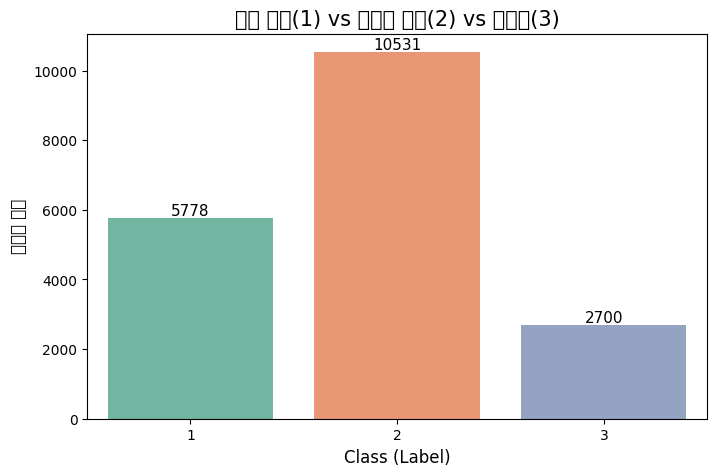

In [ ]:
# 결측치 확인
print("▶ 결측치 확인")
print(df.isnull().sum())

# 확인 결과 단순한 행 번호(index)에 2700개의 결측치(상관없는 값) 존재
# 확인해보니 미분류 값에 id 번호가 안 적혀있어 index가 결측치 처리 된 듯
# 어차피 index값은 분석과 상관없어서 preprocessing 할 때 df = df.drop(columns=['index'])로 삭제 가능
# 우리가 분석해야 할 실제 문자 메시지 내용(content) 결측치 0개
# 스미싱 여부를 알려주는 정답 라벨(class) 결측치 0개
# 여기서 말하는 결측치는 빈칸이 있나, 정답 라벨에 다른 숫자가 들어있나를 확인한 것

# 라벨(1: 정상, 2: 스미싱, 3: 미분류) 분포 확인
print("\n▶ 라벨 비율 확인 (%)")
label_counts = df['class'].value_counts(normalize=True) * 100
print(label_counts.round(2))

# 확인 결과 스미싱이 55.4%, 정상이 30.4%, 미분류가 14.2%
# 14% 미분류된 데이터는 삭제할지 preprocessing을 거쳐서 학습에 쓸지 추후 결정

# 라벨 분포 시각화
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='class', hue='class', data=df, palette='Set2', legend=False)
plt.title('정상 문자(1) vs 스미싱 문자(2) vs 미분류(3)', fontsize=15)
plt.xlabel('Class (Label)', fontsize=12)
plt.ylabel('데이터 개수', fontsize=12)

# 막대 그래프 위에 정확한 개수 표시
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=11, xytext=(0, 5),
                textcoords='offset points')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48296 (\N{HANGUL SYLLABLE BEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loc

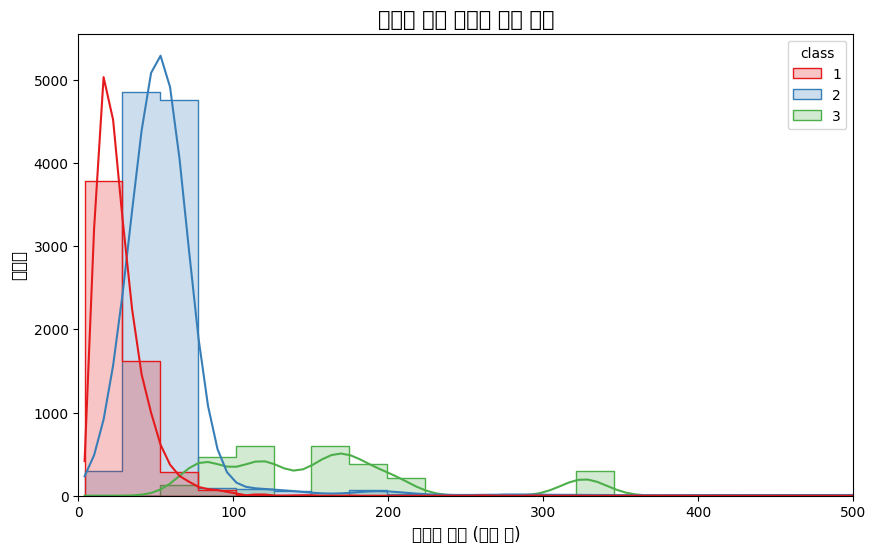

In [ ]:
# 문자 메시지 길이에 따른 분포 확인
# 메시지 내용이 담긴 실제 column명 'content'를 사용
df['text_length'] = df['content'].astype(str).apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='text_length', hue='class', bins=50, kde=True, palette='Set1', element="step")
plt.title('라벨별 문자 메시지 길이 분포', fontsize=15)
plt.xlabel('메시지 길이 (글자 수)', fontsize=12)
plt.ylabel('빈도수', fontsize=12)
plt.xlim(0, 500)
plt.show()

# 확인 결과, 대부분 메시지 길이는 100자 이하로 짧다
# 스미싱 문자가 일반 문자보다 상대적으로 길다
# 미분류된 메시지의 경우 메시지 길이가 100자부터 300자 이상까지 매우 불규칙적으로 퍼져있다. 이상치 처리 필요할 듯!

# 정상 문자와 스미싱 문자를 구분할 때, 메시지의 글자수를 feature로 쓸 수 있을 듯

In [ ]:
# 한국어 형태소 분석기 설치
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 31.5 MB/s eta 0:00:00


/tmp/ipykernel_3525/3912707355.py:50: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3525/3912707355.py:50: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3525/3912707355.py:50: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3525/3912707355.py:50: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3525/3912707355.py:50: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3525/3912707355.py:50: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3525/3912707355.py:50: UserWarning: Glyph 46988 (\N{HANGUL SYLLABLE RAM}) missing from font(s) DejaVu Sans.
  plt.tight_layo

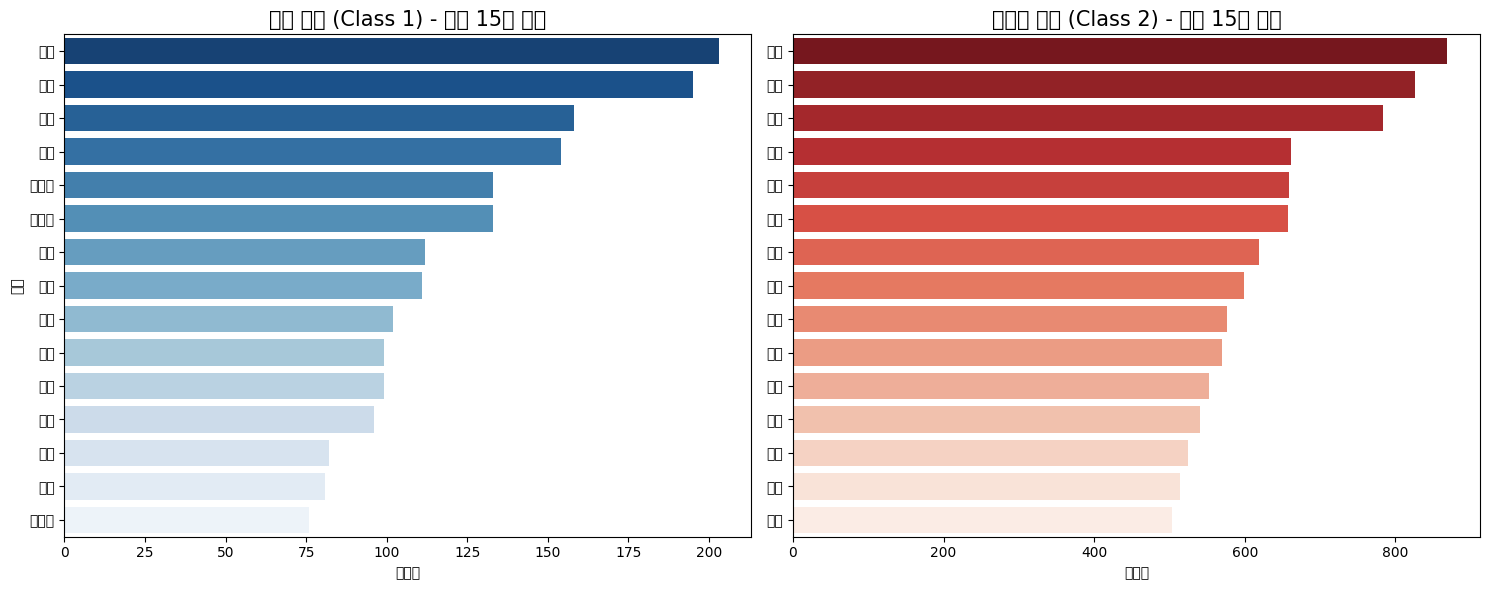

In [ ]:
# 특정 단어가 라벨 별로 얼마나 자주 등장하는지 확인 (우선 상위 15개만)

from konlpy.tag import Okt
from collections import Counter

# 형태소 분석기 초기화
okt = Okt()

# 명사 추출 및 빈도수 계산 함수 정의
def get_top_nouns(text_series, top_n=15):
    all_nouns = []
    # 각 문자 메시지에서 명사만 추출
    for text in text_series.astype(str):
        nouns = okt.nouns(text)
        # 1글자 단어는 의미를 파악하기 어려우므로 제외 (예: '것', '수', '등')
        nouns = [word for word in nouns if len(word) > 1]
        all_nouns.extend(nouns)

    # 단어별 빈도수 계산 후 상위 N개 반환
    counter = Counter(all_nouns)
    return counter.most_common(top_n)

# 클래스별로 데이터 분리 및 빈도수 계산
# class 1 (정상 문자), class 2 (스미싱 문자)
normal_texts = df[df['class'] == 1]['content']
smishing_texts = df[df['class'] == 2]['content']

top_normal_words = get_top_nouns(normal_texts, 15)
top_smishing_words = get_top_nouns(smishing_texts, 15)

# 데이터프레임으로 변환
df_normal = pd.DataFrame(top_normal_words, columns=['Word', 'Count'])
df_smishing = pd.DataFrame(top_smishing_words, columns=['Word', 'Count'])

# 시각화 (두 개의 그래프를 나란히 배치)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 정상 문자 단어 빈도 그래프
sns.barplot(x='Count', y='Word', data=df_normal, ax=axes[0], palette='Blues_r', hue='Word', legend=False)
axes[0].set_title('정상 문자 (Class 1) - 상위 15개 명사', fontsize=15)
axes[0].set_xlabel('빈도수')
axes[0].set_ylabel('단어')

# 스미싱 문자 단어 빈도 그래프
sns.barplot(x='Count', y='Word', data=df_smishing, ax=axes[1], palette='Reds_r', hue='Word', legend=False)
axes[1].set_title('스미싱 문자 (Class 2) - 상위 15개 명사', fontsize=15)
axes[1].set_xlabel('빈도수')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Data Preprocessing

In [ ]:
import pandas as pd
import re
import numpy as np
from konlpy.tag import Okt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
from IPython.display import display

# 미분류 데이터(3) 제거 및 정상(1)/스미싱(2)만 남기기
df = df[df['class'].isin([1, 2])].reset_index(drop=True)

# 분석에 불필요한 index 컬럼 삭제 (존재할 경우)
if 'index' in df.columns:
    df = df.drop(columns=['index'])

print("▶ 미분류(3) 데이터 및 불필요한 컬럼 제거 완료")
print(f"  - 현재 데이터 크기: {df.shape}")
display(df.head(5))


▶ 미분류(3) 데이터 및 불필요한 컬럼 제거 완료
  - 현재 데이터 크기: (16309, 3)


,content,class,text_length
0,엄마 나 폰이 망가져서 수리맡기고 컴퓨터 문자나라로 메시지 보내고 있어 엄마 지금 바뻐?,2,49
1,[국외발신]\n[코인원]\n고객님계정이\n해외IP에서\n로그인되였습니다.해외IP차단...,2,64
2,엄마 입금받을수있는\n은행계좌번호\n하나랑 계좌등록\n본인인증땜에\n계좌 3자리\n...,2,51
3,엄마 바빠?나지금\n핸드폰 고장나서 매장에 수리맡기고\n급한대로 예전에\n내명의로 ...,2,104
4,엄마~ 바빠?\n엄마 나 급한 일이 좀 생겨서…\n지금 98만원만 입금해 줄 수 있...,2,49


In [ ]:
# 문자 메시지에는 특수문자, 의미 없는 이모티콘, 공백, 국문/영문이 복잡하게 섞여 있음.
# 특히 스미싱 문자는 [Web발신], (광고) 같은 패턴이나 특수 기호가 많으므로 이를 정규표현식(re)으로 정제.

# 텍스트 정제-한글, 영문, 숫자와 필수 특수기호만 남기기

def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    # 한글, 영문, 숫자, 그리고 스미싱에 자주 쓰이는 특수문자([], (), /, ., :)만 남기고 제거
    text = re.sub(r'[^가-힣a-zA-Z0-9\[\]\(\)\/\.\:]', ' ', text)
    # 연속된 공백 하나로 줄이기
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_content'] = df['content'].apply(clean_text)

print("▶ 텍스트 정제(불필요한 특수문자 및 공백 제거) 완료")
print("  - [비교] 원본 데이터 vs 정제된 데이터")
display(df[['content', 'cleaned_content']].head(3))

▶ 텍스트 정제(불필요한 특수문자 및 공백 제거) 완료
  - [비교] 원본 데이터 vs 정제된 데이터


,content,cleaned_content
0,엄마 나 폰이 망가져서 수리맡기고 컴퓨터 문자나라로 메시지 보내고 있어 엄마 지금 바뻐?,엄마 나 폰이 망가져서 수리맡기고 컴퓨터 문자나라로 메시지 보내고 있어 엄마 지금 바뻐
1,[국외발신]\n[코인원]\n고객님계정이\n해외IP에서\n로그인되였습니다.해외IP차단...,[국외발신] [코인원] 고객님계정이 해외IP에서 로그인되였습니다.해외IP차단해주세요...
2,엄마 입금받을수있는\n은행계좌번호\n하나랑 계좌등록\n본인인증땜에\n계좌 3자리\n...,엄마 입금받을수있는 은행계좌번호 하나랑 계좌등록 본인인증땜에 계좌 3자리 비밀번호까...


In [ ]:
# 이상치 제거-글자 수가 0이거나 미만인 데이터(정제 후 빈 칸이 된 데이터), 혹은 데이터의 99%가 포함되는 범위를 벗어난 너무 긴 메시지(예: 500자 초과)는 학습에서 제외
# 정제 후 글자 수 다시 계산
df['text_length'] = df['cleaned_content'].apply(len)

before_len = len(df)

# 글자 수가 너무 짧거나(내용 없음) 500자를 초과하는 극단적 이상치 제거
df = df[(df['text_length'] > 0) & (df['text_length'] <= 500)].reset_index(drop=True)

print("▶ 이상치 제거 완료")
print(f"  - 제거된 데이터 개수: {before_len - len(df)}개")
print(f"  - 현재 데이터 크기: {df.shape}")

▶ 이상치 제거 완료
  - 제거된 데이터 개수: 152개
  - 현재 데이터 크기: (16157, 4)


In [ ]:
# 토큰화(Tokenization) 및 불용어 제거-명사 분석 시 상위에 나왔던 단어 중 '회원님', '고객님'처럼 정상/스미싱 모두에 너무 흔하게 쓰여서 분별력이 없는 단어나, 의미 없는 조사들을 리스트로 만들어 제외

# 불용어 리스트 예시-추가 확장 필요
stopwords = ['의', '가', '이', '은', '들', '는', '좀', '잘', '걍', '과', '도', '를', '으로', '자', '에', '와', '한', '하다']

def tokenize_and_remove_stopwords(text):
    # 명사뿐만 아니라 동사, 형용사까지 형태소 분석을 원하면 okt.morphs() 사용
    # 단어 고유의 의미를 살리려면 stem=True 옵션 추가 가능
    tokens = okt.nouns(text)
    # 1글자 제어 및 불용어 제거
    meaningful_tokens = [word for word in tokens if len(word) > 1 and word not in stopwords]
    return ' '.join(meaningful_tokens) # 단어들을 공백으로 이어붙인 문자열 반환

print("▶ 토큰화 및 불용어 제거")
df['tokenized_content'] = df['cleaned_content'].apply(tokenize_and_remove_stopwords)

print("  - [비교] 정제된 텍스트 vs 토큰화된 텍스트")
display(df[['cleaned_content', 'tokenized_content']].head(3))

▶ 토큰화 및 불용어 제거
  - [비교] 정제된 텍스트 vs 토큰화된 텍스트


,cleaned_content,tokenized_content
0,엄마 나 폰이 망가져서 수리맡기고 컴퓨터 문자나라로 메시지 보내고 있어 엄마 지금 바뻐,엄마 수리 컴퓨터 문자 메시지 엄마 지금
1,[국외발신] [코인원] 고객님계정이 해외IP에서 로그인되였습니다.해외IP차단해주세요...,국외 발신 코인 고객 계정 해외 로그인 해외 차단
2,엄마 입금받을수있는 은행계좌번호 하나랑 계좌등록 본인인증땜에 계좌 3자리 비밀번호까...,엄마 입금 은행 계좌 번호 하나 계좌 등록 본인 인증 계좌 자리 비밀번호


In [ ]:
# 중복 문자 확인 및 제거
# cleaned_content 기준으로도 가능하지만 content 기준이 데이터를 날릴 위험이 적음

# drop_duplicates() 전에 중복 개수를 먼저 확인

print("중복 제거 전 데이터 크기:", df.shape)

duplicate_count = df.duplicated(subset='content').sum()
print("중복 행 수(content 기준):", duplicate_count)

duplicated_rows = df[df.duplicated(subset='content', keep=False)]
print("중복 그룹에 포함된 전체 행 수:", len(duplicated_rows))

print("\n중복 데이터의 class 분포:")
print(duplicated_rows['class'].value_counts())
print(duplicated_rows['class'].value_counts(normalize=True) * 100)

# 클래스가 각각 어떤 유형인지
print("\nclass 1 samples:")
display(df[df['class'] == 1][['content', 'class']].head(5))

print("class 2 samples:")
display(df[df['class'] == 2][['content', 'class']].head(5))

# 중복 제거
df = df.drop_duplicates(subset='content').reset_index(drop=True)

print("\n중복 제거 후 데이터 크기:", df.shape)
print("중복 제거 후 남은 중복 행 수:", df.duplicated(subset='content').sum())

중복 제거 전 데이터 크기: (16157, 5)
중복 행 수(content 기준): 2854
중복 그룹에 포함된 전체 행 수: 5529

중복 데이터의 class 분포:
class
2    5525
1       4
Name: count, dtype: int64
class
2    99.927654
1     0.072346
Name: proportion, dtype: float64

class 1 samples:


,content,class
463,밀당보다 직진이 더매력쩔음,1
464,야구는 투수놀음이란걸 투수들 폭망이면 답이 없지,1
465,우리한테 2대0으로졌지^-^,1
466,아오 귀여워 ㅋㅋㅋ,1
467,더러운 조선족과 짱깨들은 곧 파멸을 앞두고 있구나!,1


class 2 samples:


,content,class
0,엄마 나 폰이 망가져서 수리맡기고 컴퓨터 문자나라로 메시지 보내고 있어 엄마 지금 바뻐?,2
1,[국외발신]\n[코인원]\n고객님계정이\n해외IP에서\n로그인되였습니다.해외IP차단...,2
2,엄마 입금받을수있는\n은행계좌번호\n하나랑 계좌등록\n본인인증땜에\n계좌 3자리\n...,2
3,엄마 바빠?나지금\n핸드폰 고장나서 매장에 수리맡기고\n급한대로 예전에\n내명의로 ...,2
4,엄마~ 바빠?\n엄마 나 급한 일이 좀 생겨서…\n지금 98만원만 입금해 줄 수 있...,2



중복 제거 후 데이터 크기: (13303, 5)
중복 제거 후 남은 중복 행 수: 0


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# 토큰화까지 끝난 df에서, 벡터화 전에 테스트 20%를 분리
# 데이터 누수 방지를 위해 TF-IDF와 scaler는 train set에만 fit

# 스미싱 문자를 1, 정상 문자를 0으로 변환
y = (df['class'] == 2).astype(int)

# 오답 분석에서 원문 추적을 위해 행 index 저장
indices = np.arange(len(df))

# train_text, test_text는 아직 숫자로 바꾸기 전의 문자 데이터
# train_tfidf는 문자 데이터를 TF-IDF로 바꾼 숫자 데이터
# train_length는 문자 길이를 scaling한 숫자 데이터
X_train_text, X_test_text, X_train_len, X_test_len, y_train, y_test, idx_train, idx_test = train_test_split(
    df['tokenized_content'],
    df[['text_length']],
    y,
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("▶ Train/Test Split 완료")
print(f"  - train: {len(X_train_text)}건")
print(f"  - test: {len(X_test_text)}건")
print(f"  - 학습셋 스미싱 비율: {y_train.mean():.1%}")
print(f"  - 테스트셋 스미싱 비율: {y_test.mean():.1%}\n")

# 텍스트를 TF-IDF 행렬로 변환
# fit은 train set에만 적용하고, test set에는 transform만 적용
tfidf = TfidfVectorizer(max_features=3000)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

# 메시지 길이 feature 정규화
# scaler도 train set에만 fit
scaler = StandardScaler()

X_train_length = scaler.fit_transform(X_train_len)
X_test_length = scaler.transform(X_test_len)

# TF-IDF 단어 피처와 길이 피처 결합
# train, test는 TF-IDF + text length가 결합된 최종 학습용 숫자 데이터
X_train = hstack([X_train_tfidf, X_train_length])
X_test = hstack([X_test_tfidf, X_test_length])

print("피처 생성 및 벡터화 완료")
print(f"  - train TF-IDF 피처 크기: {X_train_tfidf.shape}")
print(f"  - test TF-IDF 피처 크기: {X_test_tfidf.shape}")
print(f"  - train 길이 피처 크기: {X_train_length.shape}")
print(f"  - test 길이 피처 크기: {X_test_length.shape}")
print(f"  - 최종 X_train 크기: {X_train.shape}")
print(f"  - 최종 X_test 크기: {X_test.shape}")

▶ Train/Test Split 완료
  - train: 10642건
  - test: 2661건
  - 학습셋 스미싱 비율: 56.6%
  - 테스트셋 스미싱 비율: 56.6%

피처 생성 및 벡터화 완료
  - train TF-IDF 피처 크기: (10642, 3000)
  - test TF-IDF 피처 크기: (2661, 3000)
  - train 길이 피처 크기: (10642, 1)
  - test 길이 피처 크기: (2661, 1)
  - 최종 X_train 크기: (10642, 3001)
  - 최종 X_test 크기: (2661, 3001)


In [ ]:
# # 피처 생성 및 벡터화(ML기준)

# # 텍스트를 TF-IDF 행렬로 변환 (자주 나오면서도 독특한 단어에 가중치 부여)
# # 전체 문서에서 흔하지 않은 단어가 특정 글에 집중적으로 등장하면 점수를 높게 주기.
# tfidf = TfidfVectorizer(max_features=3000) # 상위 3000개 단어만 사용
# X_tfidf = tfidf.fit_transform(df['tokenized_content'])

# # 내가 만든 파생 변수(메시지 길이)를 2차원 배열로 변환 후 정규화(Scaling)
# # 원래 메시지들의 글자 수(45자, 120자, 500자)를 그대로 쓰면 숫자가 너무 커서 TF-IDF 점수들이 무시됨.
# # StandardScaler() 사용해 normailzation 수행.

# scaler = StandardScaler()
# X_length = scaler.fit_transform(df[['text_length']])

# # TF-IDF 단어 피처와 길이 피처를 하나로 결합 (hstack)
# # 총 3001개의 열을 가진 최종 데이터 행렬 도출(0~2999번째 열 : TF-IDF score, 3000번째 열 : normaization을 거친 메세지 길이)
# X_final = hstack([X_tfidf, X_length])
# y_final = df['class'].values

# print("피처 생성 및 벡터화 완료")
# print(f"  - TF-IDF 피처 크기: {X_tfidf.shape}")
# print(f"  - 길이 피처 크기: {X_length.shape}")
# print(f"  - 최종 학습용 데이터(X_final) 크기: {X_final.shape}")

# Modeling & Validation

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score

# #스미싱문자를 1로, 정상 문자를 0으로
# y = (y_final == 2).astype(int)

In [ ]:
# # train set, test set 분리
# # 원문 추적을 위해 행 인덱스도 같이 분리 (뒤의 오답 분석에서 사용)
# indices = np.arange(X_final.shape[0])
# X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
#     X_final, y, indices, test_size=0.2, random_state=42, stratify=y
# )
# print(f"train {X_train.shape[0]}건 / test {X_test.shape[0]}건")
# print(f"학습셋 스미싱 비율: {y_train.mean():.1%}  (테스트셋: {y_test.mean():.1%})")

In [ ]:
# 문자열 길이를 StandardScaler로 정규화했으므로 음수값을 가지는 애들이 생김
# -> MultinomialNB 사용 불가

models = {
    "DecisionTree": DecisionTreeClassifier(
        max_depth=20,
        class_weight="balanced",
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5,
        metric="cosine"
    ),

    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "LinearSVC": LinearSVC(
        class_weight="balanced",
        random_state=42
    ),
}

In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print("=" * 60)
    print(f"[{name}]  스미싱(1) F1 = {f1_score(y_test, pred):.4f}")
    print(classification_report(y_test, pred, target_names=["정상(0)", "스미싱(1)"], digits=4))

[DecisionTree]  스미싱(1) F1 = 0.8391
              precision    recall  f1-score   support

       정상(0)     0.7612    0.8831    0.8176      1155
      스미싱(1)     0.8978    0.7875    0.8391      1506

    accuracy                         0.8290      2661
   macro avg     0.8295    0.8353    0.8283      2661
weighted avg     0.8385    0.8290    0.8298      2661

[KNN]  스미싱(1) F1 = 0.9335
              precision    recall  f1-score   support

       정상(0)     0.9162    0.9091    0.9126      1155
      스미싱(1)     0.9307    0.9363    0.9335      1506

    accuracy                         0.9245      2661
   macro avg     0.9235    0.9227    0.9231      2661
weighted avg     0.9244    0.9245    0.9244      2661

[LogisticRegression]  스미싱(1) F1 = 0.9462
              precision    recall  f1-score   support

       정상(0)     0.9177    0.9463    0.9318      1155
      스미싱(1)     0.9578    0.9349    0.9462      1506

    accuracy                         0.9399      2661
   macro avg     0.9378   

이 아래에 잇는 애를 절대 클릭하지 마세요...

클릭하다 ㅋㅋ

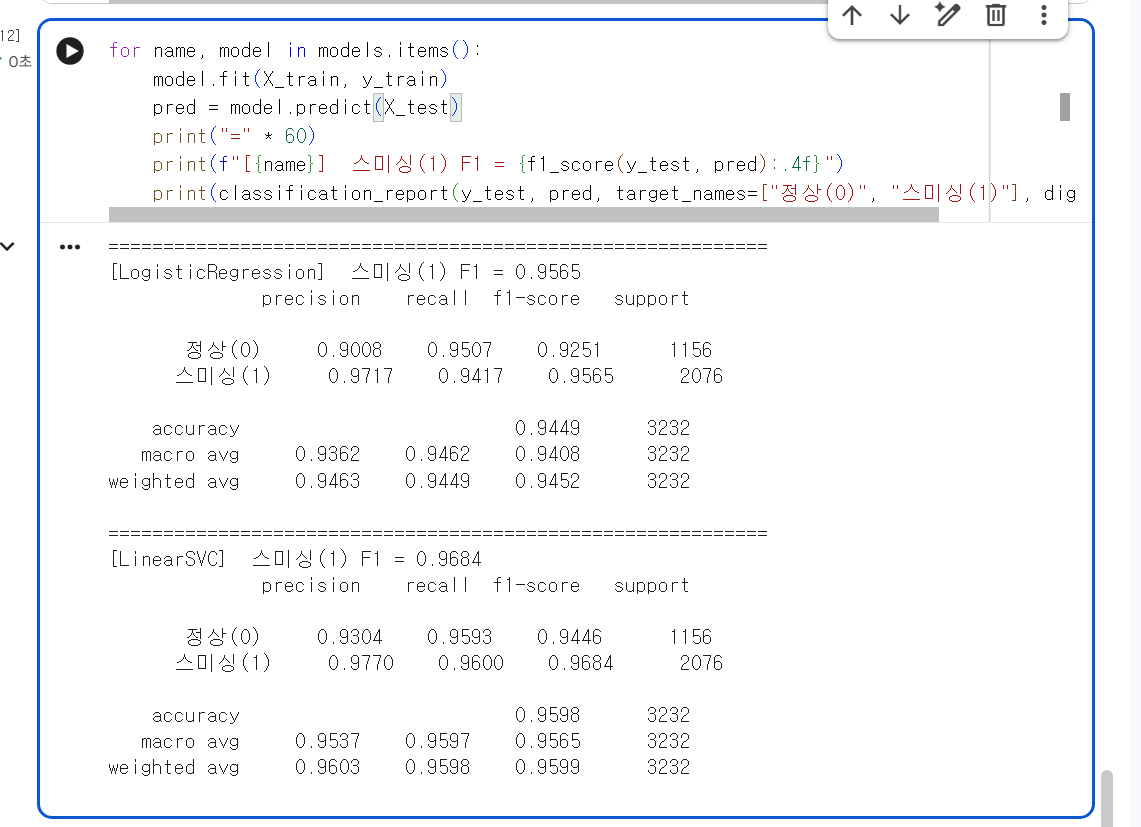

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1", ascending=False).reset_index(drop=True)

display(results_df)

,Model,Accuracy,Precision,Recall,F1
0,LinearSVC,0.957535,0.970290,0.954183,0.962169
1,LogisticRegression,0.939872,0.957823,0.934927,0.946237
2,KNN,0.924464,0.930693,0.936255,0.933466
3,DecisionTree,0.829012,0.897805,0.787517,0.839052


# Interpretation